## 텍스트 요약을 위한 LLM을 만들고 고도화 시켜보자
- 야놀자 호텔의 리뷰를 요약하는 모델을 만들고 성능을 향상시키기

In [1]:
import os
import json
import numpy as np
import seaborn as sns
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv
import datetime
from dateutil import parser
# dateutil : 다양한 형식의 날짜와 시간 문자열을 파싱하고 시간대 정보를 처리하는 모듈
 # parser : 문자열에서 날짜와 시간정보를 자동으로 인식하고 파싱하는 함수

### 1. API key 및 기본 설정

In [2]:
load_dotenv()
MY_API_KEY = os.getenv('OPENAI_API_KEY')

client = OpenAI(api_key=MY_API_KEY)

In [3]:
# 잘 연결됐는지 확인

completion = client.chat.completions.create(
    model='gpt-3.5-turbo',
    messages=[{'role':'user', 'content':'hi'}],
    temperature=1
)
print(completion.choices[0].message.content)

Hello! How can I assist you today?


### 2. 데이터 전처리
- JSON 형태의 리뷰 파일에서 각 리뷰들을 구분할 수 있는 문자열로 변환

#### 1) 수집한 리뷰 JSON 파일 로드
- 야놀자 홈페이지에서 신라스테이 역삼 호텔에 대한 리뷰를 20스크롤 정도 크롤링한 데이터 (23년 8월~24년 10월)

In [4]:
with open('data/ya_review_sinla.json', 'r', encoding='utf-8') as f :
    review_list = json.load(f)

print(len(review_list))
review_list[:10]

420


[{'review': '고민하다가 조식포함으로 결정했는데 좋은 선택이었습니다. 같이간 이들도 만족스러워했어요. 조식도 좋았고 시설, 서비스, 청결도 나무랄데가 없었네요.',
  'stars': 5,
  'date': '2024.06.03'},
 {'review': '커피쿠폰도 받았구 깨끗하고 교회뷰도 이뻤어요!!!', 'stars': 5, 'date': '2022.11.20'},
 {'review': '잊을수없는 추억을 남겼어요 너무너무 좋았어요\r\n여자친구 몰래 프로포즈를 준비하게되었는데\r\n프론트 체크인 도와주셨던 직원분께 양해를 구하고\r\n선물을 미리 맡겨주셨고 프로포즈셋팅까지 완벽하게 진행될 수 있도록 정말 많은 도움 주셨어요\r\n바쁘신 와중에도 제가 계획한대로 체크인도 도와주셨고 딜라이브 ott까지 챙겨주시는 섬세함에 감동받았습니다 나중에 기념일때 다시한번 꼭 방문하겠습니다 성함을 기억했어야 하는데 젊은 남직원분\r\n다음번 방문때 감사인사 드리겠습니다\r\n훌륭한 룸컨디션도 칭찬합니다',
  'stars': 5,
  'date': '2022.10.17'},
 {'review': '조식이 맛있어요!!다양하게 종류도 많구요 캠페인중이여서 할인도 해서 먹었는데 맛있습니다\n직원분들 친절하고 대응도 잘해주세요',
  'stars': 5,
  'date': '1일 전'},
 {'review': '가족들이 간다고 해서 진짜 폭풍 검색해서 알아봐드렸는데 좋아하셔서 좋았습니다 :) 신라스테이는 어딜 가도 좋은것 같아요',
  'stars': 5,
  'date': '3일 전'},
 {'review': '프론트 직원분들이 친절하셔서 좋아요', 'stars': 5, 'date': '3일 전'},
 {'review': '아주좋아요오오옹오ㅗ옹', 'stars': 5, 'date': '2024.10.08'},
 {'review': '청결하고 좋습니다 특히 조식이 맛있었어요', 'stars': 5, 'date': '2024.10.08'},
 {'review': '깨끗

In [24]:
import pandas as pd
df = pd.read_json('data/ya_review_sinla.json')
df['stars'].value_counts()

stars
5    346
4     56
3     11
1      4
2      3
Name: count, dtype: int64

#### 2) 높은 평점 및 낮은 평점 기준 정의
(야놀자 리뷰 요약 중에서 높은 평점만 사용할 예정)
- 전체 평균 4.7이므로 높은 평점은 5점으로 정의
- 높은 평점 : 별 5개
- 낮은 평점 : 별 4개 이하

In [5]:
star_list = [i['stars'] for i in review_list]

np.mean(star_list)

np.float64(4.754761904761905)

<Axes: ylabel='count'>

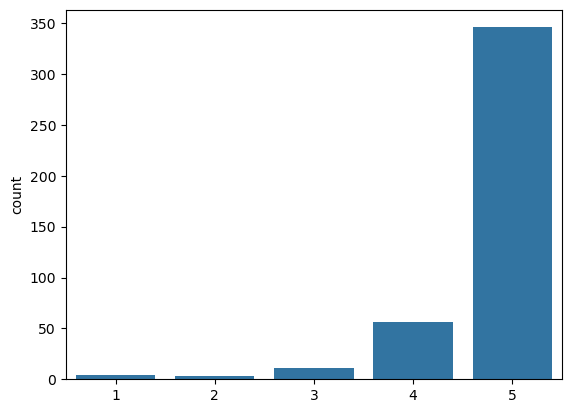

In [6]:
# 점수별 데이터 개수
sns.countplot(x=star_list)

In [7]:
# 높은 평점, 낮은 평점 개수 구하기
high_cnt, low_cnt = 0, 0

for i in review_list :
    if i['stars'] == 5:
        high_cnt += 1
    else :
        low_cnt += 1

high_cnt, low_cnt

(346, 74)

#### 3) 높은 평점만 추출
- 야놀자 홈페이지의 높은 평점리뷰 요약과 비교를 할 예정. 우리도 높은 평점 리뷰만 추출.

In [8]:
reviews_high = []

for i in review_list :
    if i['stars'] == 5:

        #평점 5점인 리뷰를 시작과 끝 구분기호로 처리해줌
        reviews_high.append('[Review_start]'+ i['review'] + '[Review_end]')

reviews_high[:5]

### 리스트 컴프리헨션 사용!!
# reviews_high = [f"[Review_start]{i['review']}[Review_end]" for i in review_list if i['stars'] == 5]

['[Review_start]고민하다가 조식포함으로 결정했는데 좋은 선택이었습니다. 같이간 이들도 만족스러워했어요. 조식도 좋았고 시설, 서비스, 청결도 나무랄데가 없었네요.[Review_end]',
 '[Review_start]커피쿠폰도 받았구 깨끗하고 교회뷰도 이뻤어요!!![Review_end]',
 '[Review_start]잊을수없는 추억을 남겼어요 너무너무 좋았어요\r\n여자친구 몰래 프로포즈를 준비하게되었는데\r\n프론트 체크인 도와주셨던 직원분께 양해를 구하고\r\n선물을 미리 맡겨주셨고 프로포즈셋팅까지 완벽하게 진행될 수 있도록 정말 많은 도움 주셨어요\r\n바쁘신 와중에도 제가 계획한대로 체크인도 도와주셨고 딜라이브 ott까지 챙겨주시는 섬세함에 감동받았습니다 나중에 기념일때 다시한번 꼭 방문하겠습니다 성함을 기억했어야 하는데 젊은 남직원분\r\n다음번 방문때 감사인사 드리겠습니다\r\n훌륭한 룸컨디션도 칭찬합니다[Review_end]',
 '[Review_start]조식이 맛있어요!!다양하게 종류도 많구요 캠페인중이여서 할인도 해서 먹었는데 맛있습니다\n직원분들 친절하고 대응도 잘해주세요[Review_end]',
 '[Review_start]가족들이 간다고 해서 진짜 폭풍 검색해서 알아봐드렸는데 좋아하셔서 좋았습니다 :) 신라스테이는 어딜 가도 좋은것 같아요[Review_end]']

In [9]:
# 리스트에 있는 리뷰들 전체를 하나의 문자열로 변환 (LLM 입력 형태는 단일 문자열)
reviews_high_txt = '\n'.join(reviews_high)
print(reviews_high_txt[:400])


[Review_start]고민하다가 조식포함으로 결정했는데 좋은 선택이었습니다. 같이간 이들도 만족스러워했어요. 조식도 좋았고 시설, 서비스, 청결도 나무랄데가 없었네요.[Review_end]
[Review_start]커피쿠폰도 받았구 깨끗하고 교회뷰도 이뻤어요!!![Review_end]
[Review_start]잊을수없는 추억을 남겼어요 너무너무 좋았어요
여자친구 몰래 프로포즈를 준비하게되었는데
프론트 체크인 도와주셨던 직원분께 양해를 구하고
선물을 미리 맡겨주셨고 프로포즈셋팅까지 완벽하게 진행될 수 있도록 정말 많은 도움 주셨어요
바쁘신 와중에도 제가 계획한대로 체크인도 도와주셨고 딜라이브 ott까지 챙겨주시는 섬세함에 감동받았습니다 나중에 기념일때 다시한번 꼭 방문하겠습니다 성함을 기억했어야 하


#### 4) 각 전처리 단계를 하나의 함수로 작성~
- 추가로 야놀자 홈페이지에서 GPT-4로 요약한 후기의 기간이 24년 10월 16일부터 이전 6개월간이므로
- 동일한 조건으로 맞춰주기 위해, 현재 리뷰 데이터도 같은 기간의 리뷰만 추출

In [10]:
# 6개월간의 리뷰만 추출하기 위해 기간 지정
# timedelta : 두 날짜 혹은 시간간의 차이를 나타내는 함수
 # 매개변수는 weeks, days, hours, minutes, seconds
 # timedelta는 고정된 길이를 반환하는데 월 단위는 28~31일 사이로 변환되어 길이가 다르고,
 # 이에 따라 년도 마찬가지로 변화되기 때문에 월과 년 기준은 없음
datetime.datetime(2024,10,16) - datetime.timedelta(weeks=24)

datetime.datetime(2024, 5, 1, 0, 0)

In [11]:
# 리뷰 전처리 함수
def preprocess_reviews(path='data/ya_review_sinla.json') : 
    with open(path, 'r', encoding='utf-8') as f :
        review_list = json.load(f)

    review_high = []

    # 기준 날짜 (데이터가 수집된 당시 기준)
    base_date = datetime.datetime(2024,10,16)

    # 6개월 전 날짜
    date_boundary = base_date - datetime.timedelta(weeks=24)

    for i in review_list :
        # 각 리뷰의 날짜를 변수에 저장 (문자열 상태)
        review_date_str = i['date']
        
        try :
            # parse : 문자열이 들어오면 코드 타입(날짜형태)으로 변환시켜주는 함수
            review_date = parser.parse(review_date_str)
        
            # 만약 에러가 발생한다면, 년월일로 표시되지 않은 데이터 값들은 parse 함수 사용시 해당 에러가 발생 ex) 2일전
            # 해당 데이터는 그냥 현재 날짜로 변경 (어차피 몇일전은 6개월 내에 포함되니까~)
        except (ValueError, TypeError) :
            review_date = base_date

        
        # 리뷰 날짜가 6개월 날짜보다 작으면(이전이면) 수집 안하고 반복문으로 돌아가
        if review_date < date_boundary :
            continue

        if i['stars'] == 5 :
            review_high.append('[Review_start]' + i['review'] + '[Review_end]')

    # 리뷰들을 개행 주어 구분하며 전체 문자열로 변환
    reviews_high_text = '\n'.join(review_high)

    return reviews_high_text

In [12]:
# review_date = parser.parse(review_date_str)
# type(review_date)
# 타입 찍어보니, datetime.datetime

In [13]:
# 전처리 함수 실행
reviews = preprocess_reviews()
print(reviews)

[Review_start]고민하다가 조식포함으로 결정했는데 좋은 선택이었습니다. 같이간 이들도 만족스러워했어요. 조식도 좋았고 시설, 서비스, 청결도 나무랄데가 없었네요.[Review_end]
[Review_start]조식이 맛있어요!!다양하게 종류도 많구요 캠페인중이여서 할인도 해서 먹었는데 맛있습니다
직원분들 친절하고 대응도 잘해주세요[Review_end]
[Review_start]가족들이 간다고 해서 진짜 폭풍 검색해서 알아봐드렸는데 좋아하셔서 좋았습니다 :) 신라스테이는 어딜 가도 좋은것 같아요[Review_end]
[Review_start]프론트 직원분들이 친절하셔서 좋아요[Review_end]
[Review_start]아주좋아요오오옹오ㅗ옹[Review_end]
[Review_start]청결하고 좋습니다 특히 조식이 맛있었어요[Review_end]
[Review_start]깨끗하고 친잘하고 교통편도 편리해요
그래서 출장중엔 종종 이용합니다[Review_end]
[Review_start]서울오면 항상들려요~[Review_end]
[Review_start]잘 아용하였습니다![Review_end]
[Review_start]편안하게 잘 쉬다 갑니다.[Review_end]
[Review_start]조식도 맛있고 주차도 편리하고 좋았습니다^^[Review_end]
[Review_start]처음 가보았는데 도시에 있어도 소음이 심하지도 않고 객실은 대체적으로 청결하고 좋았습니다[Review_end]
[Review_start]병원 방문으로 강남에 갔다가 쉴 곳이 필요해 데이유즈로 이용했습니다. 전체적으로 룸 컨디션은 5성급 호텔과 비슷한 수준으로 훌륭했고, 인근에 식당과 카페가 많이 있어 위치도 좋습니다. 
무엇보다 넓은 지하주차장을 가지고 있어, 어딜 가나 주차 스트레스가 심한 강남에서 편히 쉬다 갈 수 있었습니다.[Review_end]
[Review_start]시설이 깨끗하고 편리하게 이용함[Review_end]
[Review_start]친절 하고 깨끗해요[Re

### 3. 리뷰 문장 요약을 위한 Base 모델 개발
- base 모델(gpt-3.5-turbo)의 요약이 야놀자 후기 요약문장(gpt-4-turbo)에 근접하게 성능을 향상시켜보자

In [14]:
len(reviews)

6916

In [15]:
# 베이스 프롬프트 작성
PROMPT_BASELINE = '아래 숙소 리뷰에 대해 5문장 내로 요약해줘'

#### 1) 리뷰 요약 함수 선언

In [16]:
# LLM을 호출하여 리뷰들에 대한 요약을 진행하는 사용자 정의 함수
def summarize(reviews, prompt, temperature=0, model='gpt-3.5-turbo') :
    prompt = prompt + '\n\n' + reviews

    completion = client.chat.completions.create(
        model=model,
        messages=[{'role':'user', 'content':prompt}],
        temperature=temperature
    )

    return completion.choices[0].message.content

#### 2) 모델별 요약 결과

In [17]:
# base 모델 요약 결과
print(summarize(reviews, PROMPT_BASELINE))

조식포함으로 결정한 숙소는 시설, 서비스, 청결도 모두 만족스러웠고, 직원분들도 친절했다. 위치도 좋아서 가족들이 좋아했던 신라스테이는 깨끗하고 친절한 직원분들이 좋았다.특히 조식이 맛있었고, 주차도 편리했으며, 교통편도 편리했다. 또한, 룸 컨디션은 5성급 호텔과 비슷한 수준이었고, 주변에 식당과 카페가 많아 위치도 좋았다. 또한, 조식이 맛있고, 직원분들이 친절해서 편안한 하룻밤을 보낼 수 있었다.


In [18]:
# gpt-4-turbo 요약 결과
summary_gpt4_turbo = """청결하고 쾌적한 환경을 제공하며, 친절한 직원 서비스가 돋보입니다. 
조식은 다양한 메뉴와 맛으로 손님들에게 호평을 받으며, 주차 시설도 편리하게 마련되어 있습니다. 
객실은 아늑하고 고급스러운 분위기를 연출하며, 일부 객실에서는 도로 소음이 발생할 수 있습니다. 
접근성과 주변 식당, 카페가 다양해 이용객의 편의성이 높습니다. 전반적으로 가성비가 우수하고, 재방문 의사가 있는 곳입니다."""

### 4. 모델 평가 함수 선언
#### 1) 평가 기준 설정
- MT-Bench 논문 기반 LLM 비교 평가 방식 적용
- gpt-4o 모델 활용하여 2개의 모델(gpt-3.5-turbo, gpt-4-turbo)의 요약 결과를 평가해보자
#### 2) 평가를 위한 스크립트 및 모델 실행 코드 작성
- 기존 MT-Bench 논문의 프롬프트에서 우리의 task에 맞게 일부만 수정해서 활용

In [19]:
def pairwise_eval(reviews, answer_a, answer_b) :
    eval_prompt = f"""[System]
    Please act as an impartial judge and evaluate the quality of the Korean summaries provided by two
    AI assistants to the set of user reviews on accommodations displayed below. You should choose the assistant that
    follows the user's instructions and answers the user's question better. Your evaluation
    should consider factors such as the helpfulness, relevance, accuracy, depth, creativity,
    and level of detail of their responses. Begin your evaluation by comparing the two
    responses and provide a short explanation. Avoid any position biases and ensure that the
    order in which the responses were presented does not influence your decision. Do not allow
    the length of the responses to influence your evaluation. Do not favor certain names of
    the assistants. Be as objective as possible. After providing your explanation, output your
    final verdict by strictly following this format: "[[A]]" if assistant A is better, "[[B]]"
    if assistant B is better, and "[[C]]" for a tie.
    [User Reviews]
    {reviews}
    [The Start of Assistant A's Answer]
    {answer_a}
    [The End of Assistant A's Answer]
    [The Start of Assistant B's Answer]
    {answer_b}
    [The End of Assistant B's Answer]"""
        
    # 평가를 위한 LLM은 GPT-4o 버전으로 지정
    completion = client.chat.completions.create(
        model='gpt-4o',
        messages=[{'role': 'user', 'content': eval_prompt}],
        temperature=0
    )
    return completion.choices[0].message.content

#### 3) base모델과 4모델 하나씩의 응답에 대해서 시범 평가

In [20]:
answer_a = summarize(reviews, PROMPT_BASELINE)
answer_b = summary_gpt4_turbo

pairwise_eval(reviews, answer_a, answer_b)

"Both Assistant A and Assistant B provided summaries of the user reviews, but they approached the task differently.\n\nAssistant A's summary focuses on specific aspects mentioned in the reviews, such as the satisfaction with breakfast, the cleanliness and friendliness of the staff, and the overall positive experience. However, the summary is somewhat repetitive and lacks depth, as it mainly reiterates the positive aspects without much elaboration.\n\nAssistant B, on the other hand, provides a more structured and detailed summary. It highlights the cleanliness, the quality of the breakfast, the convenience of parking, and the comfort of the rooms. It also mentions potential downsides, such as road noise, and emphasizes the accessibility and variety of nearby amenities. This summary offers a more comprehensive view of the accommodation, including both positive aspects and potential drawbacks.\n\nOverall, Assistant B's response is more detailed and provides a balanced view of the accommod

### 5. 메인 평가 진행
- 먼저 모델 고도화 없이 base모델과 4모델의 성능을 여러번 비교 평가해보자
- 실무에서는 다양한 데이터에 대해 많은 횟수로 평가.
- 지금은 동일한 prompt에 대해 temperature를 높여서 다양한 응답을 10개 만들고 이에 대해 평가를 진행
- 50~100번 정도의 평가를 진행하면 좋지만 시간과 비용문제로...

In [27]:
# temperature를 0.8로 높여서 설정하고, 10번만큼의 base모델의 요약 결과를 리스트에 담기
import numpy as np

summarizes_baseline = [summarize(reviews, PROMPT_BASELINE, temperature=i) for i in np.arange(0, 1, 0.1)]

In [29]:
len(summarizes_baseline)

10

In [35]:
summarizes_gpt4 = [summary_gpt4_turbo for _ in range(10)]
len(summarizes_gpt4)

10

In [36]:
# 평가를 10번 반복해 base모델이 4에 비해 몇번이나 승리했는지 판단하는 함수
def pairwise_eval_batch(reviews, answer_a, answer_b) :
    a_cnt, b_cnt, c_cnt = 0, 0, 0    # 승, 패, 무

    for i in tqdm(range(10)) :
        # 1번 평가하는 함수(pairwise_eval)을 10번 진행
        result_text = pairwise_eval(reviews, answer_a[i], answer_b[i])
        if '[[A]]' in result_text :
            a_cnt += 1
        elif '[[B]]' in result_text :
            b_cnt += 1
        elif '[[C]]' in result_text :
            c_cnt += 1
        else :
            print('비상비상! 결과값 없음!')
    
    return a_cnt, b_cnt, c_cnt

In [38]:
wins, losses, ties = pairwise_eval_batch(reviews, summarizes_baseline, summarizes_gpt4)
print({wins}, {losses}, {ties})

100%|██████████| 10/10 [00:38<00:00,  3.87s/it]

{0} {10} {0}


### 6. 모델 및 프롬프트 고도화
#### 1) 프롬프트 엔지니어링 (페르소나 및 조건 명시)

In [40]:
prompt = """당신은 문장 요약 전문가입니다.
사용자 숙소 리뷰들이 주어졌을 때 이를 요약하는 것이 당신의 목표입니다.

요약 결과는 다음 조건들을 충족해야 합니다:
1. 모든 문장은 항상 존댓말로 끝나야 합니다.
2. 숙소에 대해 소개하는 톤앤매너로 작성해주세요.
 2-1. 좋은 리뷰 요약 예시
  a) 전반적으로 좋은 숙소였고 방음도 괜찮았다는 평입니다.
  b) 재방문 예정이라는 평들이 존재합니다.
 2-2. 나쁜 리뷰 요약 예시
  a) 좋은 숙소였고 방음도 괜찮음.
  b) 재방문 예정.
3. 요약 결과는 최소 4문장 이상 최대 7문장 이내로 작성해주세요.

아래 숙소 리뷰들에 대해 요약해주세요:
"""

# 변경한 프롬프트로 base모델로 10번 요약 실행
summaries_opt1 = [summarize(reviews, prompt, temperature=0.8) for _ in range(10)]

In [41]:
wins, losses, ties = pairwise_eval_batch(reviews, summaries_opt1, summarizes_gpt4)
print({wins}, {losses}, {ties})

100%|██████████| 10/10 [00:42<00:00,  4.29s/it]

{4} {6} {0}


- 몇몇 응답 case에서는 base모델이 이긴 것을 확인할 수 있음 (성능 향상!)

#### 2) 입력 데이터의 품질 향상
- 실제 숙소에 대한 정보가 포함되지 않는 단순하고 짧은 리뷰들은 필터링 ex) 좋았어요, 굳굳굳 등

In [53]:
# 전처리 함수 가져와서 코드 일부 변경
 # 1) 일정 리뷰 길이 미만(저품질 예상) 필터링
 # 2) 남은 양질의 리뷰 개수 출력

def preprocess_reviews(path='data/ya_review_sinla.json') : 
    with open(path, 'r', encoding='utf-8') as f :
        review_list = json.load(f)

    review_high = []

    base_date = datetime.datetime(2024,10,16)
    date_boundary = base_date - datetime.timedelta(weeks=24)

    filtered_cnt = 0      # 필터링 된 리뷰 개수 카운트용

    for i in review_list :
        review_date_str = i['date']
        
        try :
            review_date = parser.parse(review_date_str)

        except (ValueError, TypeError) :
            review_date = base_date

        
        if review_date < date_boundary :
            continue

        # 리뷰 길이가 15 미만이면 다시 되돌아감
        if len(i['review']) < 15 :
            filtered_cnt += 1
            continue

        if i['stars'] == 5 :
            review_high.append('[Review_start]' + i['review'] + '[Review_end]')

    # min함수 활용해 15자 이상인 리뷰들의 개수가 50개보다 적으면, 리뷰 개수만큼만 사용
    # 50개보다 많더라도 50개로 제한 (gpt-3.5는 context window의 제한으로 입력이 길면 에러발생할 수 있음)
    review_high = review_high[ : min(len(review_high), 50)]
    print('15자 미만 리뷰 개수: ', filtered_cnt)
    print('필터링 되고 남은 리뷰 개수:', len(review_high))

    reviews_high_text = '\n'.join(review_high)

    return reviews_high_text

In [54]:
# 변경된 전처리 함수를 리뷰 데이터에 다시 적용
reviews = preprocess_reviews()

15자 미만 리뷰 개수:  42
필터링 되고 남은 리뷰 개수: 50


In [57]:
summaries_opt2 = [summarize(reviews, prompt, temperature=0.8) for _ in range(10)]

In [58]:
wins, losses, ties = pairwise_eval_batch(reviews, summaries_opt2, summarizes_gpt4)
print({wins}, {losses}, {ties})

100%|██████████| 10/10 [00:46<00:00,  4.67s/it]

{5} {5} {0}


- 입력데이터 중에서 요약에 도움이 되지 않는 데이터들을 줄여주는 것만으로도 성능 향상 이룰 수 있음
- 하지만 그만큼 입력된 데이터 수 적고, 테스트 횟수가 많지 않기 때문에 범용적으로 좋은 모델이라고 판단하긴 어려움

#### 3) Few-shot learning
- 질의-응답 쌍을 넣어줘야 하는데, **새로운 숙소의 리뷰와 그 요약**을 예시로 넣어주자

In [59]:
# 글래드 강남 코엑스센터 호텔의 리뷰를 불러와서 전처리 진행
reviews_1shot = preprocess_reviews('data/ya_review_glad.json')

15자 미만 리뷰 개수:  56
필터링 되고 남은 리뷰 개수: 50


In [61]:
# 요약문 예시 생성
# 좀 더 좋은 예시를 위해 상급모델 사용, 출력 문장을 일정하게 하기 위해 temp 값 0 설정

summary_1shot = summarize(reviews_1shot, prompt, temperature=0, model='gpt-4o')
summary_1shot

'글래드 삼성 호텔은 편리한 위치와 깔끔한 시설로 많은 고객들에게 사랑받고 있습니다. 삼성역과 가까워 교통이 편리하며, 코엑스와 현대백화점 등 주요 명소와의 접근성도 뛰어납니다. 침구가 매우 편안하다는 평이 많아 숙박의 질이 높으며, 친절한 직원들의 서비스도 인상적이라는 의견이 많습니다. 다만, 일부 고객들은 소음 문제를 지적하기도 했으나 전반적으로 만족도가 높은 숙소입니다. 다양한 부대시설과 합리적인 가격으로 가성비가 좋다는 평가도 받고 있습니다.'

In [ ]:
prompt_1shot = f"""당신은 문장 요약 전문가입니다.
사용자 숙소 리뷰들이 주어졌을 때 이를 요약하는 것이 당신의 목표입니다.

요약 결과는 다음 조건들을 충족해야 합니다:
1. 모든 문장은 항상 존댓말로 끝나야 합니다.
2. 숙소에 대해 소개하는 톤앤매너로 작성해주세요.
 2-1. 좋은 리뷰 요약 예시
  a) 전반적으로 좋은 숙소였고 방음도 괜찮았다는 평입니다.
  b) 재방문 예정이라는 평들이 존재합니다.
 2-2. 나쁜 리뷰 요약 예시
  a) 좋은 숙소였고 방음도 괜찮음.
  b) 재방문 예정.
3. 요약 결과는 최소 4문장 이상 최대 7문장 이내로 작성해주세요.

다음은 참고할 리뷰와 그에 대한 요약 메시지 입니다.
[예시 리뷰]
{reviews_1shot}
[예시 요약 결과]
{summary_1shot}

아래 숙소 리뷰들에 대해 요약해주세요.
"""

# glad 호텔 리뷰와 요약예시가 들어간 프롬프트로 gpt-3.5가 요약 진행
summaries_opt3 = [summarize(reviews, prompt_1shot, temperature=0.8) for _ in range(10)]

In [65]:
wins, losses, ties = pairwise_eval_batch(reviews, summaries_opt3, summarizes_gpt4)
print({wins}, {losses}, {ties})

100%|██████████| 10/10 [00:45<00:00,  4.53s/it]

{1} {9} {0}


- 1shot 프롬프팅 후 결과가 들쭉날쭉. 현재 질의-응답 예시가 길어서 예시를 충분히 반영하지 못했을 수 있음
- 예시로 너무 긴 데이터를 넣으면... 모델의 context window의 크기 고려해야 함
- 입력되는 텍스트의 양이 많으면 중요한 지시사항을 잊거나 데이터의 노이즈(오타, 특문)까지 신경써서 응답해버릴 수 있음
- 프롬프트 엔지니어링은 테스트와 그에 따른 통계치 추출이 필수적인 파트

#### 4) two-shot prompting으로 예시를 좀 더 줘보자

In [66]:
# two shot 예시를 위해 호텔인나인 리뷰를 가져와서 추가적으로 활용

reviews_2shot = preprocess_reviews('data/ya_review_in9.json')

reviews_2shot

15자 미만 리뷰 개수:  42
필터링 되고 남은 리뷰 개수: 46


'[Review_start]야경이 멋졌고 21층 식사 (디너)가 진짜 맛있었어요!\n코엑스도 가까워서 호캉스하기 좋았어요...\n또 갈거에요^^[Review_end]\n[Review_start]깔끔해서 잘 잘수 있었습니다.[Review_end]\n[Review_start]매우 좋았습니다. 서비스도 만족스럽습니다.[Review_end]\n[Review_start]침구가 편하고 주차가 편해요[Review_end]\n[Review_start]저녁 늦게 갔다가 잘 쉬고 갑니다.[Review_end]\n[Review_start]침구류가 좋아요 주차도 편하구요[Review_end]\n[Review_start]후기들 보고 처음가봣는데 침대도 엄청 편하고 뷰도 좋아요[Review_end]\n[Review_start]침구가 좋아요 주차도 발렛해주시고 좋아요[Review_end]\n[Review_start]좋은 위치 편리한 주변 시설 편안한 침구 등 덕분에 나흘 동안 잘 쉬고 잘 지냈습니다[Review_end]\n[Review_start]여자친구와 연휴에 잘 쉬다갑니다[Review_end]\n[Review_start]편하게 이용합니다. \n친절하고 깨끗하고[Review_end]\n[Review_start]전체적으로 위치가 너무 좋았어요[Review_end]\n[Review_start]침구가 좋으며 룸도 넓어 좋아요[Review_end]\n[Review_start]급하게 이용하게되었는데 좋았습니다[Review_end]\n[Review_start]침구류가 넓고 편안해서 좋아요[Review_end]\n[Review_start]일단 코엑스와 접근성이 엄청 좋습니다~봉은사역에서 호텔까지 1분거리구요!! 침구도 푹신해서 좋았어요    지금 이벤트기간이라 무료미니바도 좋았어요[Review_end]\n[Review_start]위치좋고 친철하고 좋습니다 \n세탁이 덜된 상태인거같아 별다른 이야긴하지않았으나 침대시트에 립스틱입술자국이 있더군요 ;;[Review_end]\n[Review_start

In [67]:
summary_2shot = summarize(reviews_2shot, prompt_1shot,
                          temperature=0, model='gpt-4o')

In [68]:
summary_2shot

'이 숙소는 코엑스와 가까운 위치 덕분에 접근성이 뛰어나며, 특히 야경이 멋지다는 평이 많습니다. 침구가 편안하고 객실이 깔끔하여 숙박의 질이 높다는 의견이 많습니다. 주차가 편리하고 발렛 서비스도 제공되어 고객들이 편리하게 이용할 수 있습니다. 다만, 일부 고객들은 도로 소음과 라운지바의 부족한 서비스에 대해 아쉬움을 표했습니다. 전반적으로 친절한 직원들과 청결한 시설로 만족도가 높은 숙소입니다.'

In [69]:
prompt_2shot = f"""당신은 문장 요약 전문가입니다.
사용자 숙소 리뷰들이 주어졌을 때 이를 요약하는 것이 당신의 목표입니다.

요약 결과는 다음 조건들을 충족해야 합니다:
1. 모든 문장은 항상 존댓말로 끝나야 합니다.
2. 숙소에 대해 소개하는 톤앤매너로 작성해주세요.
 2-1. 좋은 리뷰 요약 예시
  a) 전반적으로 좋은 숙소였고 방음도 괜찮았다는 평입니다.
  b) 재방문 예정이라는 평들이 존재합니다.
 2-2. 나쁜 리뷰 요약 예시
  a) 좋은 숙소였고 방음도 괜찮음.
  b) 재방문 예정.
3. 요약 결과는 최소 4문장 이상 최대 7문장 이내로 작성해주세요.

다음은 참고할 리뷰와 그에 대한 요약 메시지 입니다.
[예시 리뷰1]
{reviews_1shot}
[예시 요약 결과1]
{summary_1shot}

[예시 리뷰2]
{reviews_2shot}
[예시 요약 결과2]
{summary_2shot}

아래 숙소 리뷰들에 대해 요약해주세요.
"""

# glad 호텔 리뷰와 요약예시가 들어간 프롬프트로 gpt-3.5가 요약 진행
summaries_opt4 = [summarize(reviews, prompt_2shot, temperature=0.8) for _ in range(10)]

In [70]:
wins, losses, ties = pairwise_eval_batch(reviews, summaries_opt4, summarizes_gpt4)
print({wins}, {losses}, {ties})

100%|██████████| 10/10 [00:51<00:00,  5.11s/it]

{6} {4} {0}


## [실습] 자유롭게 프롬프트 및 데이터를 변경하여 성능을 높여보자
- 평가 횟수는 20번으로 상향 (3.5-turbo와 4-turbo 모두 20개씩 요약 추출하고, 평가도 20회로 변경하여 진행)
- LLM이나 외부 소프트웨어 도움없이 직접 변경할 것
- 가장 Wins가 높을 때의 결과 캡처 및 설명 달아서 슬랙에 올릴 것

In [ ]:
summeries_gpt4_20 = [summary_gpt4_turbo for _ in range(20)]

In [76]:
system_prompt = f"""당신은 문장 요약 전문가입니다.
호텔에 대한 리뷰들이 주어졌을 때 이를 요약하는 것이 당신의 목표입니다.

요약 결과는 다음 조건들을 충족해야 합니다:
1. 모든 문장은 항상 존댓말로 끝나야 합니다.
2. 숙소에 대해 소개하는 톤앤매너로 작성해주세요.
 2-1. 좋은 리뷰 요약 예시
  a) 전반적으로 좋은 숙소였고 방음도 괜찮았다는 평입니다.
  b) 재방문 예정이라는 평들이 존재합니다.
 2-2. 나쁜 리뷰 요약 예시
  a) 좋은 숙소였고 방음도 괜찮음.
  b) 재방문 예정.
3. 요약 결과는 최소 4문장 이상 최대 7문장 이내로 작성해주세요.

다음은 참고할 리뷰와 그에 대한 요약 메시지 입니다.
[예시 리뷰]
{reviews_2shot}
[예시 요약 결과]
{summary_2shot}

아래 숙소 리뷰들에 대해 요약해주세요.
"""

20자 미만 리뷰 개수:  62
필터링 되고 남은 리뷰 개수: 28
[Review_start]야경이 멋졌고 21층 식사 (디너)가 진짜 맛있었어요!
코엑스도 가까워서 호캉스하기 좋았어요...
또 갈거에요^^[Review_end]
[Review_start]매우 좋았습니다. 서비스도 만족스럽습니다.[Review_end]
[Review_start]후기들 보고 처음가봣는데 침대도 엄청 편하고 뷰도 좋아요[Review_end]
[Review_start]침구가 좋아요 주차도 발렛해주시고 좋아요[Review_end]
[Review_start]좋은 위치 편리한 주변 시설 편안한 침구 등 덕분에 나흘 동안 잘 쉬고 잘 지냈습니다[Review_end]
[Review_start]편하게 이용합니다. 
친절하고 깨끗하고[Review_end]
[Review_start]일단 코엑스와 접근성이 엄청 좋습니다~봉은사역에서 호텔까지 1분거리구요!! 침구도 푹신해서 좋았어요    지금 이벤트기간이라 무료미니바도 좋았어요[Review_end]
[Review_start]위치좋고 친철하고 좋습니다 
세탁이 덜된 상태인거같아 별다른 이야긴하지않았으나 침대시트에 립스틱입술자국이 있더군요 ;;[Review_end]
[Review_start]객실이 깨끗하고 좋았어요.
다만 라운지바는 그냥 없는 거랑 비슷했고.. 식빵조차 없었어요 차도 객실에 비치되는 티백이고.. 그래서 라운지바는 없다고 봐도 무방해요.
대로변 차 소음이 좀 시끄럽고 코너 룸은 한쪽 창이 건물 벽에 가리지만 청결도나 접근성은 아주 좋아요.[Review_end]
[Review_start]굿굿 좋아요 굿굿 너무 좋아요 다음에 또 올래요[Review_end]
[Review_start]지하철역과 아주 가까웠고 늦은시간 체크인이이었으나 지친기색없이 아주 친절하게 도와주셨습니다. 층고가 높아 비교적 좁은 방이었으나 쾌적하고 침구가 아주 깨끗했습니다.[Review_end]
[Review_start]호텔의 전반적인 시설은 매우 만족스러웠습니다. 객실도 깔

In [102]:
# =========== 전처리 함수

def preprocess_reviews(path='data/ya_review_sinla.json') : 
    with open(path, 'r', encoding='utf-8') as f :
        review_list = json.load(f)

    review_high = []

    base_date = datetime.datetime(2024,10,16)
    date_boundary = base_date - datetime.timedelta(weeks=24)

    filtered_cnt = 0      # 필터링 된 리뷰 개수 카운트용

    for i in review_list :
        review_date_str = i['date']
        
        try :
            review_date = parser.parse(review_date_str)

        except (ValueError, TypeError) :
            review_date = base_date

        
        if review_date < date_boundary :
            continue

        # 리뷰 길이가 20자 미만이면 다시 되돌아감
        if len(i['review']) < 20 :
            filtered_cnt += 1
            continue

        if i['stars'] == 5 :
            review_high.append('[Review_start]' + i['review'] + '[Review_end]')


    review_high = review_high[ : min(len(review_high), 60)]
    print('20자 미만 리뷰 개수: ', filtered_cnt)
    print('필터링 되고 남은 리뷰 개수:', len(review_high))

    reviews_high_text2 = '\n'.join(review_high)

    return reviews_high_text2


# ======= LLM을 호출하여 리뷰들에 대한 요약을 진행하는 사용자 정의 함수
def summarize2(reviews, prompt, sys_msg, temperature=1, model='gpt-3.5-turbo') :
    prompt = prompt + '\n\n' + reviews

    completion = client.chat.completions.create(
        model=model,
        messages=[
        {'role':'system', 'content': sys_msg},
         {'role':'user', 'content':prompt}],
        temperature=temperature
    )

    return completion.choices[0].message.content

# ======================== 평가를 위한 스크립트
def pairwise_eval2(reviews, answer_a, answer_b) :
    eval_prompt = f"""[System]
    Please act as an impartial judge and evaluate the quality of the Korean summaries provided by two
    AI assistants to the set of user reviews on accommodations displayed below. You should choose the assistant that
    follows the user's instructions and answers the user's question better. Your evaluation
    should consider factors such as the helpfulness, relevance, accuracy, depth, creativity,
    and level of detail of their responses. Begin your evaluation by comparing the two
    responses and provide a short explanation. Avoid any position biases and ensure that the
    order in which the responses were presented does not influence your decision. Do not allow
    the length of the responses to influence your evaluation. Do not favor certain names of
    the assistants. Be as objective as possible. After providing your explanation, output your
    final verdict by strictly following this format: "[[A]]" if assistant A is better, "[[B]]"
    if assistant B is better, and "[[C]]" for a tie.
    [User Reviews]
    {reviews}
    [The Start of Assistant A's Answer]
    {answer_a}
    [The End of Assistant A's Answer]
    [The Start of Assistant B's Answer]
    {answer_b}
    [The End of Assistant B's Answer]"""
        
    # 평가를 위한 LLM은 GPT-4o 버전으로 지정
    completion = client.chat.completions.create(
        model='gpt-4o',
        messages=[{'role': 'user', 'content': eval_prompt}],
        temperature=0
    )
    return completion.choices[0].message.content


# ================ 평가를 20번 반복해 base모델이 4에 비해 몇번이나 승리했는지 판단하는 함수
def pairwise_eval_batch2(reviews, answer_a, answer_b) :
    a_cnt, b_cnt, c_cnt = 0, 0, 0    # 승, 패, 무

    for i in tqdm(range(20)) :
        # 1번 평가하는 함수(pairwise_eval)을 10번 진행
        result_text = pairwise_eval2(reviews, answer_a[i], answer_b[i])
        if '[[A]]' in result_text :
            a_cnt += 1
        elif '[[B]]' in result_text :
            b_cnt += 1
        elif '[[C]]' in result_text :
            c_cnt += 1
        else :
            print('비상비상! 결과값 없음!')
    
    return a_cnt, b_cnt, c_cnt

In [103]:
# summarize2로 다른 호텔 리뷰 요약하고, sys_msg 적용
reviews_2shot = preprocess_reviews('data/ya_review_in9.json')

summary_2shot = summarize2(reviews_2shot, prompt, "당신은 요약 전문가입니다",
                          temperature=0, model='gpt-4o')

system_prompt = f"""당신은 문장 요약 전문가입니다.
호텔에 대한 리뷰들이 주어졌을 때 이를 요약하는 것이 당신의 목표입니다.

요약 결과는 다음 조건들을 충족해야 합니다:
1. 모든 문장은 항상 존댓말로 끝나야 합니다.
2. 숙소에 대해 소개하는 톤앤매너로 작성해주세요.
 2-1. 좋은 리뷰 요약 예시
  a) 전반적으로 좋은 숙소였고 방음도 괜찮았다는 평입니다.
  b) 재방문 예정이라는 평들이 존재합니다.
 2-2. 나쁜 리뷰 요약 예시
  a) 좋은 숙소였고 방음도 괜찮음.
  b) 재방문 예정.
3. 요약 결과는 최소 4문장 이상 최대 7문장 이내로 작성해주세요.

다음은 참고할 리뷰와 그에 대한 요약 메시지 입니다.
[예시 리뷰]
{reviews_2shot}
[예시 요약 결과]
{summary_2shot}

아래 숙소 리뷰들에 대해 요약해주세요."""

print(summary_2shot)

20자 미만 리뷰 개수:  62
필터링 되고 남은 리뷰 개수: 28
이 숙소는 코엑스와의 접근성이 뛰어나며, 봉은사역과도 가까워 교통이 매우 편리하다는 평입니다. 객실은 깔끔하고 침구가 편안하여 숙박객들이 만족스러워하고 있습니다. 특히 21층에서의 식사가 맛있다는 리뷰가 많아 식사 경험도 훌륭하다고 할 수 있습니다. 다만, 일부 객실에서는 도로 소음이 들릴 수 있으며, 라운지바의 제공 품목이 부족하다는 의견도 있습니다. 전반적으로 직원들의 친절한 서비스와 청결한 시설로 인해 재방문 의사를 밝히는 고객들이 많습니다.


In [104]:
summaries_gpt3_20 = [summarize2(reviews, prompt_2shot, system_prompt, temperature=1) for _ in range(20)]

wins, losses, ties = pairwise_eval_batch2(reviews, summaries_gpt3_20, summeries_gpt4_20)
print({wins}, {losses}, {ties})

100%|██████████| 20/20 [01:21<00:00,  4.07s/it]

{14} {6} {0}
